<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/24_10_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hamerson Joel Piarpuezan

#ACTIVIDAD

# 🔷 Modulaciones: PAM, PWM, PPM, AM y FM — Demostraciones matemáticas detalladas

En este documento se presentan **PAM (Pulse Amplitude Modulation)**, **PWM (Pulse Width Modulation)**, **PPM (Pulse Position Modulation)**, y adicionalmente **AM (Amplitude Modulation)** y **FM (Frequency Modulation)**.  
Para cada esquema se ofrece: definición, construcción en tiempo, derivación espectral (paso a paso) y notas sobre PSD/recuperación.

## Notación común
- Señal mensaje continua: $x(t)$ (se asume acotada; cuando convenga, de banda limitada con ancho $B_x$).
- Pulso elemental: $p(t)$ con transformada $P(f)=\mathcal{F}\{p(t)\}$.
- Período de símbolos/pulsos: $T_s$, frecuencia de símbolos $f_s = 1/T_s$.
- Transformada de Fourier: $X(f)=\mathcal{F}\{x(t)\}=\int_{-\infty}^{\infty} x(t)e^{-j2\pi f t}\,dt$.
- Delta de Dirac: $\delta(t)$.

---

## 1) PAM — Pulse Amplitude Modulation

### 1.1 Definición en tiempo
La señal PAM se define por:
$$
s_{\text{PAM}}(t) = \sum_{n=-\infty}^{\infty} x(nT_s)\, p(t - nT_s),
$$
con $p(t)$ pulso base (por ejemplo rectangular de ancho $\tau$).

### 1.2 Reescritura como convolución
Sea el tren de impulsos ponderado $a(t)=\sum_n x(nT_s)\delta(t-nT_s)$. Entonces:
$$
s_{\text{PAM}}(t) = a(t) * p(t).
$$

### 1.3 Transformada de Fourier (paso a paso)
- La TF de $a(t)$ es una función periódica (réplicas) en frecuencia:
$$
A(f) = \mathcal{F}\{a(t)\} = \sum_{n} x(nT_s) e^{-j2\pi f nT_s}
= \frac{1}{T_s}\sum_{k=-\infty}^{\infty} X\!\left(f - k f_s\right)
$$
(en el caso de muestreo ideal y relación adecuada entre \(X(f)\) y la DTFT; la expresión refleja la periodicidad con periodo $f_s$).
- Multiplicando por $P(f)$ (TF del pulso) se obtiene:
$$
S_{\text{PAM}}(f) = A(f)\cdot P(f) = \frac{1}{T_s}\sum_{k=-\infty}^{\infty} X\big(f - k f_s\big)\, P(f).
$$

### 1.4 Observaciones
- El espectro de $x(t)$ se replica cada $f_s$ y cada réplica está filtrada por $P(f)$.
- Para reconstrucción sin aliasing: $f_s>2B_x$.
- PSD práctica: usar Welch; se verán réplicas y envolvente $|P(f)|^2$.

---

## 2) PWM — Pulse Width Modulation

### 2.1 Modelos en tiempo
**Modelo 1 (ancho variable):**
$$
\tau_n = \alpha + \beta\, x(nT),\qquad 0\le \tau_n \le T,
$$
$$
s_{\text{PWM}}(t) = \sum_n A\cdot \Pi\!\Big(\frac{t - nT - \tau_n/2}{\tau_n}\Big).
$$

**Modelo 2 (comparador):** con referencia $r(t)$ periódica (triangular/sawtooth):
$$
s_{\text{PWM}}(t)=A\cdot \mathbf{1}_{\{x(t)>r(t)\}}.
$$

### 2.2 Análisis por series de Fourier (intuitivo)
- Para duty fijo $D=\tau/T$, un pulso periódico tiene coeficientes:
$$
c_k = A D \ \mathrm{sinc}(kD)\ e^{-j\pi k D},
$$
con frecuencias armónicas $k/T$.
- Si $D$ varía en cada periodo, los coeficientes se vuelven dependientes de la secuencia $\{D_n\}$; la DTFT de $\{D_n\}$ (proporcional a $\{x(nT)\}$) modula las amplitudes de los armónicos $k/T$.

### 2.3 Aproximación lineal (pequeñas variaciones)
Si $D_n = D_0 + \delta D_n$ con $\delta D_n \propto x(nT)$ (pequeño), entonces:
- El término constante produce los armónicos fijos.
- El término $\delta D_n$ inserta la DTFT de $\{\delta D_n\}$ alrededor de los armónicos, es decir la información del mensaje aparece como variación de las amplitudes de los armónicos.

### 2.4 Observaciones de PSD
- PSD con picos en $k/T$; envolvente dependiendo de la variación del duty y de la forma de pulso (sinc²).
- Recuperación de $x(t)$: aplicar filtro pasa-bajo que extraiga la envolvente/media del duty.

---

## 3) PPM — Pulse Position Modulation

### 3.1 Definición en tiempo
Sea $\Delta_n = k_p\, x(nT)$ el desplazamiento temporal en el $n$-ésimo pulso. Entonces:
$$
s_{\text{PPM}}(t) = \sum_{n} A \, p\big(t - nT - \Delta_n\big).
$$

### 3.2 Propiedad de desplazamiento en frecuencia
La TF de un pulso desplazado $p(t-t_0)$ es $P(f)e^{-j2\pi f t_0}$. Aplicando:
$$
S_{\text{PPM}}(f) = A\, P(f)\sum_{n} e^{-j2\pi f (nT + \Delta_n)}
= A\, P(f)\sum_{n} e^{-j2\pi f nT} e^{-j2\pi f \Delta_n}.
$$

### 3.3 Expansión para $\Delta_n$ pequeños
Usando $e^{-j2\pi f \Delta_n} \approx 1 - j2\pi f \Delta_n - \tfrac{(2\pi f \Delta_n)^2}{2} + \dots$:
$$
S_{\text{PPM}}(f) \approx A P(f)\Big[\sum_n e^{-j2\pi f nT} - j2\pi f\sum_n \Delta_n e^{-j2\pi f nT} + \cdots\Big].
$$
- El primer término da las réplicas base.
- El segundo contiene la DTFT de $\{\Delta_n\}$ (proporcional a $\{x(nT)\}$) multiplicada por $-j2\pi f$.

### 3.4 Interpretación
- La información aparece en la fase de las réplicas; en la primera aproximación se obtiene un factor $f$ que amplifica la contribución en frecuencias altas (limitado por $P(f)$).
- PSD práctica: promedio de $|S_{\text{PPM}}(f)|^2$ sobre la estadística de $\Delta_n$; la parte informativa suele aparecer como variaciones alrededor de las réplicas.

---

## 4) AM — Amplitude Modulation (Modulación en Amplitud)

### 4.1 Tipos y definición básica
Consideremos la **AM de banda lateral completa con portadora** (DSB-FC) y la **AM con banda lateral única** (SSB) para contraste. Tomaremos la forma clásica de AM con portadora:

Se transmite:
$$
s_{\text{AM}}(t) = \big[1 + k_a x(t)\big] \, A_c \cos(2\pi f_c t),
$$
donde:
- $x(t)$ es señal moduladora (normalizada para que $|k_a x(t)|\le 1$),
- $A_c$ es la amplitud de la portadora,
- $f_c$ es la frecuencia de la portadora,
- $k_a$ es el índice de modulación (sensibilidad).

### 4.2 Expandir y transformar (DSB-FC)
Para analizar el espectro, escribimos:
$$
s_{\text{AM}}(t) = A_c\cos(2\pi f_c t) + A_c k_a x(t)\cos(2\pi f_c t).
$$
- El primer término es la portadora puro en $f_c$.
- El segundo es el producto $x(t)\cos(2\pi f_c t)$, cuya TF es una **modulación en frecuencia** (desplazamiento) del espectro de $x(t)$:
Usando la propiedad de modulación:
$$
\mathcal{F}\{x(t)\cos(2\pi f_c t)\} = \tfrac{1}{2}\big(X(f - f_c) + X(f + f_c)\big).
$$
Por tanto:
$$
S_{\text{AM}}(f) = \tfrac{A_c}{2}\big[\delta(f-f_c) + \delta(f+f_c)\big] + \tfrac{A_c k_a}{2}\big[X(f - f_c) + X(f + f_c)\big].
$$

### 4.3 Interpretación
- El espectro tiene la portadora en $\pm f_c$ y **dos réplicas** del espectro del modulador centradas en $\pm f_c$ (bandas laterales superior e inferior).
- Ancho ocupado ≈ $2B_x$ (si $X(f)$ es de banda $B_x$ around DC).
- Para AM comercial convencional (transmisión de audio), se filtra/limita $x(t)$ a $f_m \le 5$ kHz; por eso cada emisora AM ocupa ~10 kHz.

### 4.4 Índice de modulación y distorsión
- Índice de modulación: $m = k_a \, A_x$, donde $A_x$ es amplitud máxima de $x(t)$.
- Si $m>1$ hay **sobre-modulación** y se generan distorsiones (inversión de envolvente).

### 4.5 PSD y demodulación
- PSD mostrará portadora y bandas laterales.
- Demodulación por detección de envolvente (rectificador + filtro) recupera $x(t)$ si $m\le 1$ y si la portadora es estable.
- Alternativa: demodulación coherente (multiplicar por $\cos(2\pi f_c t)$ y filtrar) recupera $x(t)$ sin la necesidad de detectar envolvente.

---

## 5) FM — Frequency Modulation (Modulación en Frecuencia)

### 5.1 Definición básica (FM angular y de frecuencia)
La FM típica se define como una portadora cuya **frecuencia instantánea** varía con $x(t)$. Matemáticamente:

- **Desviación angular (phase)**
$$
\theta(t) = 2\pi f_c t + 2\pi k_f \int_{0}^{t} x(\tau)\, d\tau,
$$
donde $k_f$ es la sensibilidad en Hz por unidad de $x(t)$ (si se usa $k_f$ con unidades Hz/volt). Entonces la señal FM es:
$$
s_{\text{FM}}(t) = A_c \cos\big(\theta(t)\big) = A_c \cos\!\Big(2\pi f_c t + 2\pi k_f \int_{0}^{t} x(\tau)\, d\tau\Big).
$$

- Frecuencia instantánea:
$$
f_i(t) = \frac{1}{2\pi}\frac{d\theta(t)}{dt} = f_c + k_f x(t).
$$

### 5.2 Análisis espectral — Carácter no lineal (Carson y desarrollo por series)
FM es no lineal respecto a $x(t)$. Para el caso de una sola sinusoidal $x(t)=A_m\cos(2\pi f_m t)$, hay una expresión analítica usando **funciones de Bessel**:

Sea el índice de modulación $\beta$ definido por:
$$
\beta = \frac{\Delta f}{f_m} = \frac{k_f A_m}{f_m},
$$
donde $\Delta f = k_f A_m$ es la desviación máxima de frecuencia. Para $x(t)=A_m\cos(2\pi f_m t)$:
$$
s_{\text{FM}}(t) = A_c \cos\Big(2\pi f_c t + \beta \sin(2\pi f_m t)\Big).
$$

Usando la expansión de Jacobi-Anger:
$$
\cos\big(2\pi f_c t + \beta \sin(2\pi f_m t)\big) = \sum_{n=-\infty}^{\infty} J_n(\beta)\cos\big(2\pi(f_c + n f_m)t\big),
$$
donde $J_n(\beta)$ son funciones de Bessel de primer tipo. Por tanto el espectro consiste en **líneas discretas** (componentes) en $f_c + n f_m$ con amplitudes $A_c J_n(\beta)$.

### 5.3 Regla de Carson (ancho aproximado)
La **Regla de Carson** da una estimación del ancho de banda total que contiene la mayor parte de la energía:
$$
B_{\text{Carson}} \approx 2(\Delta f + f_m) = 2 f_m (\beta + 1).
$$
Para señales de múltiples componentes, se toma $f_m$ como la máxima frecuencia del mensaje.

### 5.4 Observaciones
- FM **distribuye** la energía en múltiples bandas (sidebands) cuya amplitud depende de $\beta$ (mayor $\beta$ ⇒ más sidebands significativas ⇒ mayor ancho).
- FM es más resistente al ruido de amplitud; la relación señal-ruido en salida mejora si se usa discriminador y preénfasis/deénfasis en transmisión de audio.
- PSD práctica: para una señal moduladora compleja, el espectro es continuo con componentes alrededor de $f_c$ extendiéndose según $\Delta f$ y la estructura del mensaje. Welch puede estimar esta PSD.

---

## 6) Comparativo rápido (espectro y recuperación)

- **PAM**: réplicas directas del espectro del mensaje en múltiplos de $f_s$; reconstrucción por interpolación (filtro pasa-bajo) si $f_s>2B_x$.
- **PWM**: información en el duty; espectro con armónicos en $k/T$ y envolvente que lleva la información; recuperar con filtro pasa-bajo.
- **PPM**: información en desplazamiento temporal; espectro con fase modulada; recuperación sensible a jitter y requiere sincronización.
- **AM**: banda lateral con réplicas en $f_c\pm f$; recuperación por detección (envelope) o demodulación coherente.
- **FM**: múltiples bandas laterales (Bessel), ancho depende del índice $\beta$; resistente a ruido de amplitud, requiere discriminador/coherente para demodulación.

---

## 7) Notas sobre PSD y estimadores numéricos

- Para estimar PSD numéricamente use `scipy.signal.welch` con parámetros: `nperseg` (resolución), ventana (Hann), `noverlap` (reducción de varianza).
- Welch entrega una estimación suavizada (menor varianza) comparada con el periodograma (más ruidoso).
- En modulaciones no lineales (PWM, FM en general) la PSD exacta puede ser compleja; la estimación práctica y la interpretación (picos, envolvente, anchura) son claves.

---

## 8) Conclusión matemática
- PAM representa una **muestreo en amplitud**; su espectro se entiende claramente como réplicas de $X(f)$ filtradas por $P(f)$.
- PWM y PPM codifican la información en parámetros no lineales (ancho y posición) y su análisis requiere considerar la secuencia de parámetros ($\{D_n\}$ o $\{\Delta_n\}$); mediante linearizaciones se puede relacionar su espectro con $X(f)$.
- AM y FM son modulaciones clásicas analógicas con transformadas bien definidas (AM: desplazamiento lineal del espectro; FM: expansión en bandas laterales con coeficientes de Bessel para sinusoidales).
- Para estimaciones prácticas de PSD, Welch es la herramienta habitual; para análisis teórico, usar transformadas, DTFT y desarrollos en series (Bessel/Taylor) según corresponda.



#CODIGOS

IMPORTAR LIBRERIAS

In [4]:
# CELDA 0: imports y utilidades (ejecutar una vez)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import torch
import torch.nn as nn
import torch.optim as optim

# Ajustes estéticos para matplotlib
plt.rcParams['figure.figsize'] = (10,3)
plt.rcParams['image.interpolation'] = 'nearest'

# Función auxiliar para graficar PSD
def plot_psd_from_signal(x, fs, nperseg=1024, noverlap=None, xlim=None, title=None):
    f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=noverlap if noverlap is not None else nperseg//2)
    plt.figure(figsize=(10,3))
    plt.semilogy(f, Pxx + 1e-20)  # evitar log(0)
    if xlim is not None:
        plt.xlim(0, xlim)
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [V^2/Hz]')
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    return f, Pxx


#PAM — Celda 1A: Señal y PSD (Welch)

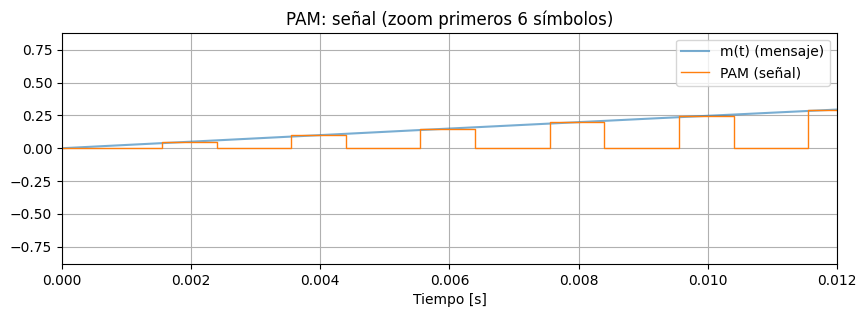

/tmp/ipython-input-2064589718.py:15: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 4000, using nperseg = 4000
  f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=noverlap if noverlap is not None else nperseg//2)


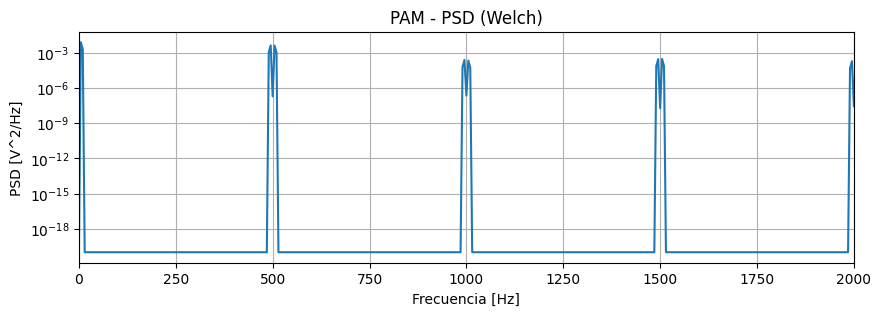

In [5]:
# CELDA 1A: PAM — generar señal, graficar y PSD por Welch

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros (puedes ajustarlos)
fs = 20000.0            # frecuencia de muestreo [Hz]
T = 0.2                 # duración total [s]
t = np.arange(0, T, 1/fs)

# Señal mensaje (ejemplo seno)
fm = 5.0                # frecuencia del mensaje [Hz]
m = 0.8 * np.sin(2*np.pi*fm*t)   # mensaje en [-0.8,0.8]

# Parámetros PAM
fsym = 500.0            # tasa de símbolos (pulsos por s)
Ts = 1.0/fsym
tau = 0.4 * Ts          # ancho de pulso (fracción del periodo)
A = 1.0

# Generar PAM: cada periodo colocamos un pulso rectangular de ancho tau con amplitud = muestra
pam = np.zeros_like(t)
n_max = int(np.floor(T * fsym))
for n in range(n_max):
    center = n * Ts
    idx_center = int(round(center * fs))
    if idx_center >= len(t):
        break
    amp = m[idx_center]
    left = int(np.round((center - tau/2) * fs))
    right = int(np.round((center + tau/2) * fs))
    left = max(left, 0)
    right = min(right, len(t)-1)
    pam[left:right+1] += amp

# 1) Grafica la señal (mensaje + PAM) — zoom primeros 6 simbolos
plt.figure(figsize=(10,3))
plt.plot(t, m, label='m(t) (mensaje)', alpha=0.6)
plt.plot(t, pam, drawstyle='steps-pre', label='PAM (señal)', linewidth=1)
plt.xlim(0, 6*Ts)
plt.xlabel('Tiempo [s]')
plt.title('PAM: señal (zoom primeros 6 símbolos)')
plt.legend(); plt.grid(); plt.show()

# 2) PSD por Welch (llamamos a la función auxiliar)
f_w, Pxx = plot_psd_from_signal(pam, fs=fs, nperseg=4096, noverlap=2048, xlim=2000, title='PAM - PSD (Welch)')


#PAM: PSD estimada por red neuronal

Epoch 40/120 - loss: 1.7998e-04
Epoch 80/120 - loss: 1.7953e-04
Epoch 120/120 - loss: 1.7952e-04


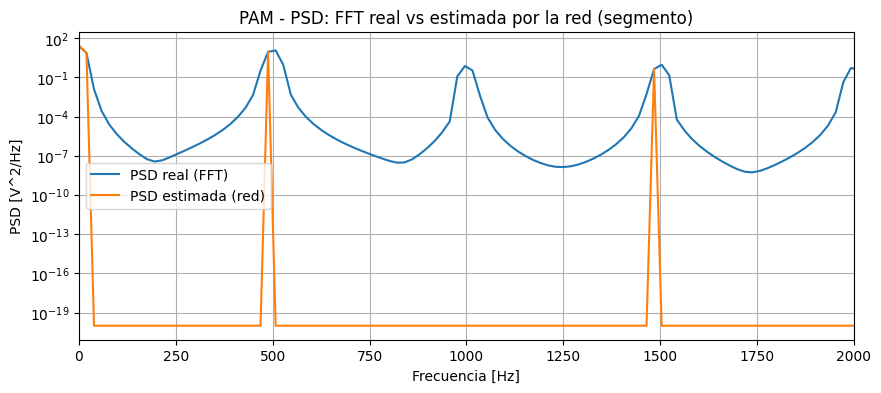

In [6]:
# CELDA 1B: PAM — entrenar red para aproximar PSD (segmentos -> PSD)
# Nota: esta celda regenera PAM internamente, por lo que puedes ejecutar 1B independientemente
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

# -----------------------
# Regenerar señal PAM (mismos parametros que 1A)
fs = 20000.0
T = 0.2
t = np.arange(0, T, 1/fs)
fm = 5.0
m = 0.8 * np.sin(2*np.pi*fm*t)
fsym = 500.0
Ts = 1.0/fsym
tau = 0.4 * Ts
pam = np.zeros_like(t)
n_max = int(np.floor(T * fsym))
for n in range(n_max):
    center = n * Ts
    idx_center = int(round(center * fs))
    if idx_center >= len(t): break
    amp = m[idx_center]
    left = int(np.round((center - tau/2) * fs))
    right = int(np.round((center + tau/2) * fs))
    left = max(left, 0); right = min(right, len(t)-1)
    pam[left:right+1] += amp

# -----------------------
# Crear dataset: segmentos temporales -> PSD (FFT magnitude^2)
seg_len = 1024
hop = 512
segments = []
psds = []
window = np.hanning(seg_len)
for start in range(0, len(pam)-seg_len, hop):
    seg = pam[start:start+seg_len]
    S = np.fft.rfft(seg * window)
    P = (np.abs(S)**2) / seg_len
    segments.append(seg.astype(np.float32))
    psds.append(P.astype(np.float32))

X = np.stack(segments)   # shape (N, seg_len)
Y = np.stack(psds)      # shape (N, seg_len/2+1)

# Normalizar entradas y salidas para entrenamiento estable
X_mean = X.mean(); X_std = X.std()
Xn = (X - X_mean) / (X_std + 1e-12)
Y_max = Y.max()
Yn = Y / (Y_max + 1e-12)

# Tensores
X_tensor = torch.tensor(Xn, dtype=torch.float32)
Y_tensor = torch.tensor(Yn, dtype=torch.float32)

# -----------------------
# Definir red MLP sencilla
class PSDNet(nn.Module):
    def __init__(self, seg_len, out_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(seg_len, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, out_len),
            nn.ReLU()   # salida no negativa (PSD)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PSDNet(seg_len, Y_tensor.shape[1]).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# DataLoader
dataset = torch.utils.data.TensorDataset(X_tensor, Y_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# Entrenamiento rápido (demo)
epochs = 120
for epoch in range(epochs):
    running_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(device); yb = yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        running_loss += loss.item() * xb.size(0)
    if (epoch+1) % 40 == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {running_loss/len(dataset):.4e}")

# -----------------------
# Evaluación: comparar un segmento real vs estimado
test_idx = min(5, Xn.shape[0]-1)
test_seg = Xn[test_idx]
test_tensor = torch.tensor(test_seg, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    pred_norm = model(test_tensor).cpu().numpy().squeeze()

# Reconstruir PSD real para ese segmento
seg_real = X[test_idx]
S_real = np.fft.rfft(seg_real * window)
P_real = (np.abs(S_real)**2) / seg_len

# Escalar la predicción (la red predice Yn i.e. normalizada)
pred_scaled = pred_norm * (Y_max + 1e-12)

# Graficar comparación PSD
freqs = np.fft.rfftfreq(seg_len, d=1/fs)
plt.figure(figsize=(10,4))
plt.semilogy(freqs, P_real + 1e-20, label='PSD real (FFT)')
plt.semilogy(freqs, pred_scaled + 1e-20, label='PSD estimada (red)')
plt.xlim(0, 2000)
plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD [V^2/Hz]')
plt.title('PAM - PSD: FFT real vs estimada por la red (segmento)')
plt.legend(); plt.grid(); plt.show()


#PWM: señal y PSD (Welch)

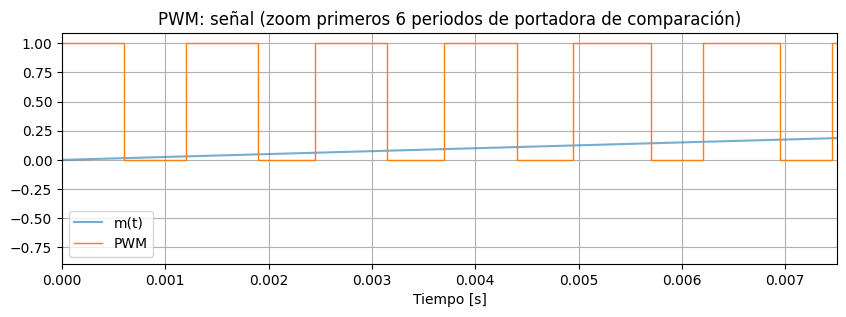

/tmp/ipython-input-392392929.py:33: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 4000, using nperseg = 4000
  f_w, Pxx = welch(pwm, fs=fs, nperseg=4096, noverlap=2048)


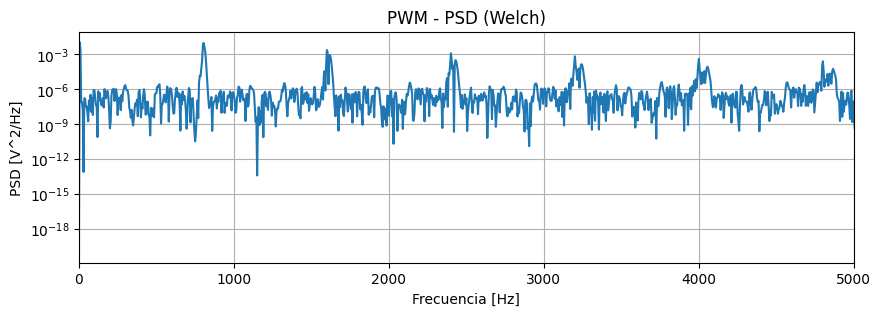

In [7]:
# CELDA 2A: PWM — generar señal, graficar y PSD por Welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 20000.0
T = 0.2
t = np.arange(0, T, 1/fs)
fm = 5.0
m = 0.8 * np.sin(2*np.pi*fm*t)

# Parámetros PWM
fsym = 800.0                    # freq de la onda de comparación (portadora de r)
samples_per_sym = int(fs/fsym)
# crear onda triangular/sawtooth de referencia en [-1,1]
r = np.tile(np.linspace(-1, 1, samples_per_sym, endpoint=False),
            int(np.ceil(len(t)/samples_per_sym)))[:len(t)]

# PWM por comparación
pwm = np.where(m > r, 1.0, 0.0)

# Graficar (zoom primeros 6 periodos de referencia)
Ts = 1.0/fsym
plt.figure(figsize=(10,3))
plt.plot(t, m, label='m(t)', alpha=0.6)
plt.plot(t, pwm, drawstyle='steps-pre', label='PWM', linewidth=1)
plt.xlim(0, 6*Ts)
plt.title('PWM: señal (zoom primeros 6 periodos de portadora de comparación)')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# PSD por Welch
f_w, Pxx = welch(pwm, fs=fs, nperseg=4096, noverlap=2048)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlim(0, 5000)
plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD [V^2/Hz]')
plt.title('PWM - PSD (Welch)')
plt.grid(); plt.show()


#PWM: PSD por red neuronal

Epoch 40 loss 7.3517e-06
Epoch 80 loss 6.9053e-06
Epoch 120 loss 6.9013e-06


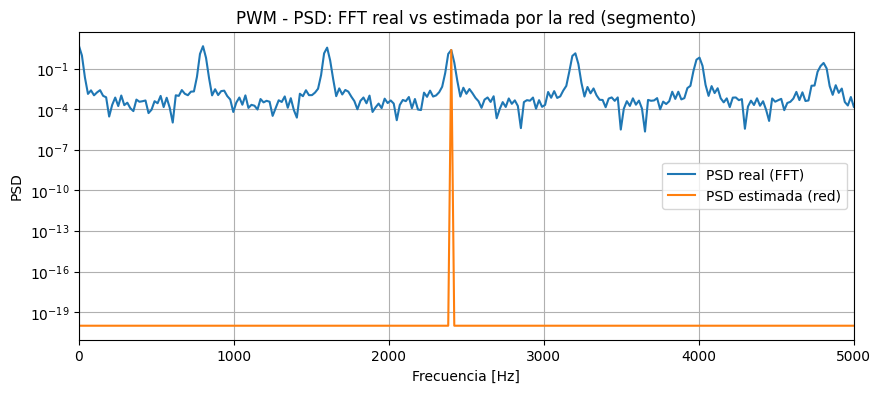

In [8]:
# CELDA 2B: PWM — PSD por Red neuronal (PyTorch)
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

# Regenerar PWM
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 5.0; m = 0.8 * np.sin(2*np.pi*fm*t)
fsym = 800.0; samples_per_sym = int(fs/fsym)
r = np.tile(np.linspace(-1, 1, samples_per_sym, endpoint=False),
            int(np.ceil(len(t)/samples_per_sym)))[:len(t)]
pwm = np.where(m > r, 1.0, 0.0)

# Dataset segmentos -> PSD
seg_len = 1024; hop = 512
window = np.hanning(seg_len)
segments=[]; psds=[]
for start in range(0, len(pwm)-seg_len, hop):
    seg = pwm[start:start+seg_len]
    S = np.fft.rfft(seg * window)
    P = (np.abs(S)**2) / seg_len
    segments.append(seg.astype(np.float32)); psds.append(P.astype(np.float32))
X = np.stack(segments); Y = np.stack(psds)

# Normalizar
Xn = (X - X.mean())/(X.std()+1e-12)
Yn = Y / (Y.max()+1e-12)

# Tensores
X_tensor = torch.tensor(Xn, dtype=torch.float32)
Y_tensor = torch.tensor(Yn, dtype=torch.float32)

# Modelo MLP
class PSDNet(nn.Module):
    def __init__(self, seg_len, out_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(seg_len, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, out_len), nn.ReLU()
        )
    def forward(self,x): return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PSDNet(seg_len, Y_tensor.shape[1]).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_tensor, Y_tensor),
                                     batch_size=32, shuffle=True)

# Entrenamiento demo
for epoch in range(120):
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    if (epoch+1) % 40 == 0:
        print(f"Epoch {epoch+1} loss {running/len(loader):.4e}")

# Evaluación: comparar segmento real vs estimado
test_idx = min(6, Xn.shape[0]-1)
test_seg = Xn[test_idx]; test_tensor = torch.tensor(test_seg, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    pred_norm = model(test_tensor).cpu().numpy().squeeze()

seg_real = X[test_idx]
S_real = np.fft.rfft(seg_real * window)
P_real = (np.abs(S_real)**2) / seg_len
pred_scaled = pred_norm * (Y.max() + 1e-12)

freqs = np.fft.rfftfreq(seg_len, d=1/fs)
plt.figure(figsize=(10,4))
plt.semilogy(freqs, P_real + 1e-20, label='PSD real (FFT)')
plt.semilogy(freqs, pred_scaled + 1e-20, label='PSD estimada (red)')
plt.xlim(0, 5000); plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD')
plt.title('PWM - PSD: FFT real vs estimada por la red (segmento)')
plt.legend(); plt.grid(); plt.show()


#PPM: señal y PSD (Welch)

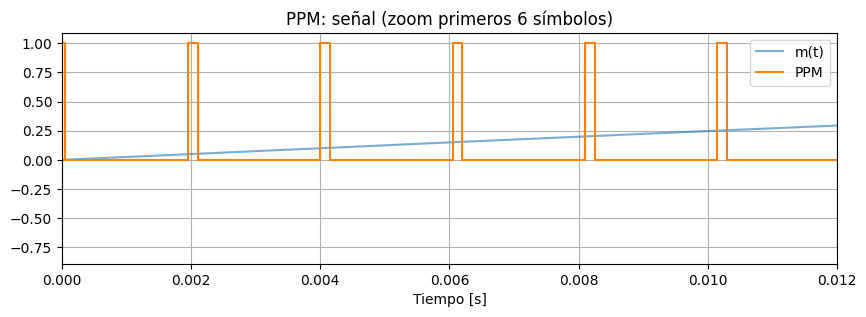

/tmp/ipython-input-3904728452.py:38: UserWarning: nperseg=4096 is greater than signal length max(len(x), len(y)) = 4000, using nperseg = 4000
  f_w, Pxx = welch(ppm, fs=fs, nperseg=4096, noverlap=2048)


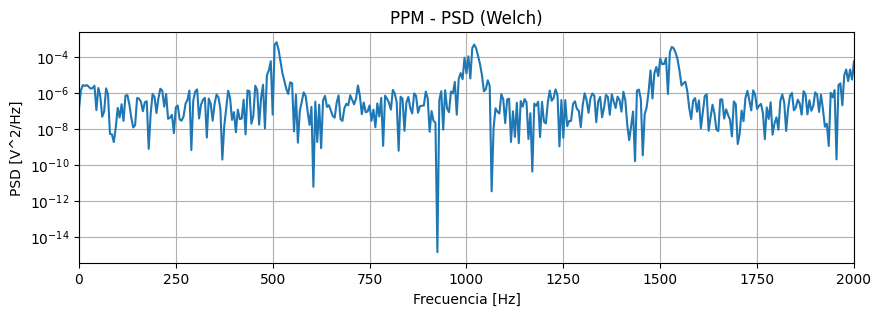

In [9]:
# CELDA 3A: PPM — generar señal, graficar y PSD por Welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 5.0; m = 0.8 * np.sin(2*np.pi*fm*t)

# Parámetros PPM
fsym = 500.0; Ts = 1.0/fsym
tau = 0.03 * Ts   # ancho del pulso corto
A = 1.0
n_max = int(np.floor(T * fsym))

# k_p normaliza m a desplazamiento máximo 0.4*Ts
k_p = 0.4 * Ts / (np.max(np.abs(m)) + 1e-12)
ppm = np.zeros_like(t)
for n in range(n_max):
    idx = int(round(n*Ts*fs))
    if idx >= len(t): break
    delta = k_p * m[idx]
    center = n*Ts + delta
    left = int(np.round((center - tau/2) * fs))
    right = int(np.round((center + tau/2) * fs))
    left = max(left,0); right = min(right, len(t)-1)
    ppm[left:right+1] += A

# Graficar (zoom primeros 6 Ts)
plt.figure(figsize=(10,3))
plt.plot(t, m, label='m(t)', alpha=0.6)
plt.plot(t, ppm, drawstyle='steps-pre', label='PPM')
plt.xlim(0, 6*Ts)
plt.title('PPM: señal (zoom primeros 6 símbolos)')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# PSD (Welch)
f_w, Pxx = welch(ppm, fs=fs, nperseg=4096, noverlap=2048)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlim(0, 2000); plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD [V^2/Hz]')
plt.title('PPM - PSD (Welch)'); plt.grid(); plt.show()


#PPM: PSD por red neuronal

Epoch 40 loss 9.7002e-04
Epoch 80 loss 9.6263e-04
Epoch 120 loss 9.6251e-04


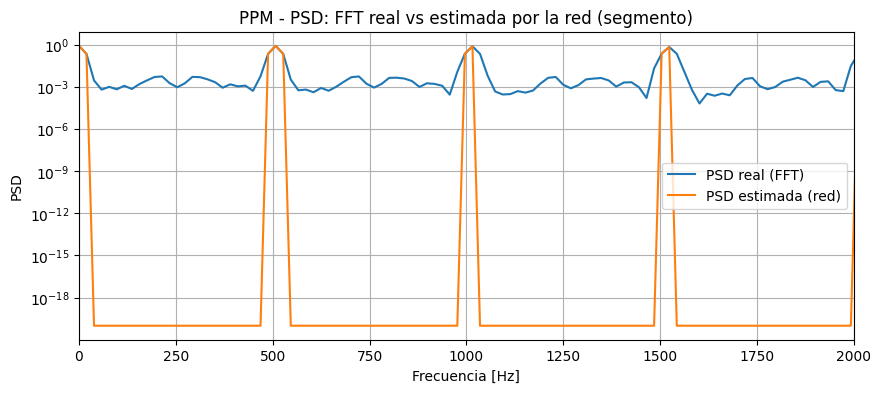

In [10]:
# CELDA 3B: PPM — PSD por Red neuronal (PyTorch)
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

# Regenerar PPM
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 5.0; m = 0.8 * np.sin(2*np.pi*fm*t)
fsym = 500.0; Ts = 1.0/fsym; tau = 0.03*Ts; A = 1.0
n_max = int(np.floor(T * fsym))
k_p = 0.4 * Ts / (np.max(np.abs(m)) + 1e-12)
ppm = np.zeros_like(t)
for n in range(n_max):
    idx = int(round(n*Ts*fs))
    if idx >= len(t): break
    delta = k_p * m[idx]
    center = n*Ts + delta
    left = int(np.round((center - tau/2) * fs)); right = int(np.round((center + tau/2) * fs))
    left = max(left,0); right = min(right, len(t)-1)
    ppm[left:right+1] += A

# Dataset segmentos -> PSD
seg_len = 1024; hop = 512; window = np.hanning(seg_len)
segments=[]; psds=[]
for start in range(0, len(ppm)-seg_len, hop):
    seg = ppm[start:start+seg_len]
    S = np.fft.rfft(seg * window)
    P = (np.abs(S)**2)/seg_len
    segments.append(seg.astype(np.float32)); psds.append(P.astype(np.float32))
X = np.stack(segments); Y = np.stack(psds)
Xn = (X - X.mean())/(X.std()+1e-12); Yn = Y / (Y.max()+1e-12)
X_tensor = torch.tensor(Xn, dtype=torch.float32); Y_tensor = torch.tensor(Yn, dtype=torch.float32)

# Modelo MLP
class PSDNet(nn.Module):
    def __init__(self, seg_len, out_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(seg_len, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, out_len), nn.ReLU()
        )
    def forward(self,x): return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PSDNet(seg_len, Y_tensor.shape[1]).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_tensor, Y_tensor),
                                     batch_size=32, shuffle=True)

for epoch in range(120):
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    if (epoch+1) % 40 == 0:
        print(f"Epoch {epoch+1} loss {running/len(loader):.4e}")

# Evaluación
test_idx = min(4, Xn.shape[0]-1)
test_seg = Xn[test_idx]; test_tensor = torch.tensor(test_seg, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    pred_norm = model(test_tensor).cpu().numpy().squeeze()

seg_real = X[test_idx]
S_real = np.fft.rfft(seg_real * window)
P_real = (np.abs(S_real)**2) / seg_len
pred_scaled = pred_norm * (Y.max()+1e-12)

freqs = np.fft.rfftfreq(seg_len, d=1/fs)
plt.figure(figsize=(10,4))
plt.semilogy(freqs, P_real + 1e-20, label='PSD real (FFT)')
plt.semilogy(freqs, pred_scaled + 1e-20, label='PSD estimada (red)')
plt.xlim(0, 2000); plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD')
plt.title('PPM - PSD: FFT real vs estimada por la red (segmento)')
plt.legend(); plt.grid(); plt.show()


#AM: señal y PSD (Welch)

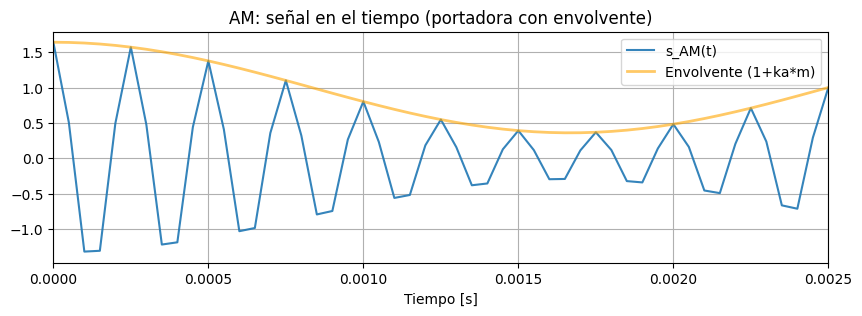

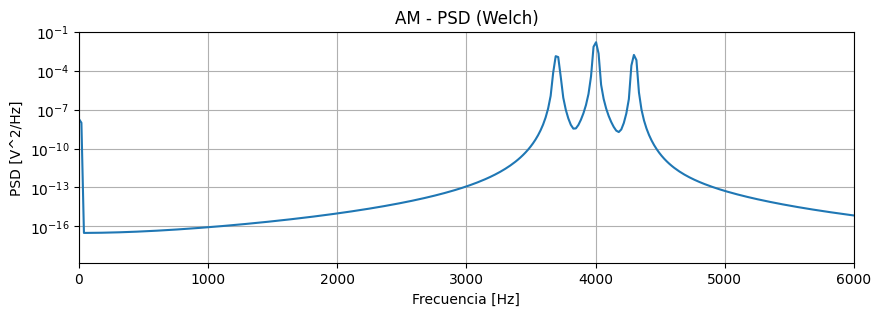

In [12]:
# CELDA 4A: AM — generar señal, graficar y PSD por Welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 300.0                      # frecuencia del tono modulador [Hz]
m = 0.8 * np.cos(2*np.pi*fm*t)  # señal moduladora

# AM params
Ac = 1.0; fc = 4000.0; ka = 0.8
s_am = Ac * (1 + ka * m) * np.cos(2*np.pi*fc*t)

# Grafica en tiempo (portadora con envolvente)
plt.figure(figsize=(10,3))
plt.plot(t, s_am, label='s_AM(t)', alpha=0.9)
plt.plot(t, Ac*(1+ka*m), label='Envolvente (1+ka*m)', color='orange', linewidth=2, alpha=0.6)
plt.xlim(0, 10/fc)
plt.title('AM: señal en el tiempo (portadora con envolvente)')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# PSD (Welch)
f_w, Pxx = welch(s_am, fs=fs, nperseg=1024, noverlap=512)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlim(0, fc + 2000)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V^2/Hz]')
plt.title('AM - PSD (Welch)')
plt.grid(True)
plt.show()


#AM: PSD por red neuronal

Epoch 60 loss 1.2926e-05
Epoch 120 loss 1.2884e-05
Epoch 180 loss 1.2883e-05


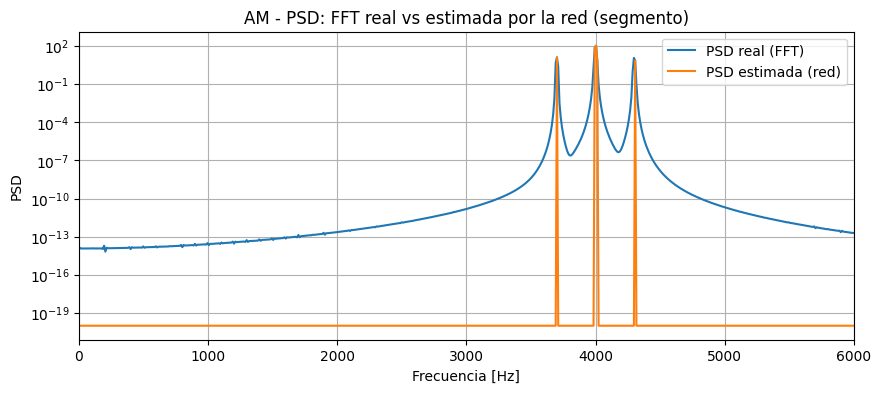

In [13]:
# CELDA 4B: AM — PSD por Red neuronal (PyTorch)
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

# Regenerar AM
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 300.0; m = 0.8 * np.cos(2*np.pi*fm*t)
Ac = 1.0; fc = 4000.0; ka = 0.8
s_am = Ac * (1 + ka * m) * np.cos(2*np.pi*fc*t)

# Dataset segmentos -> PSD
seg_len = 2048; hop = 1024; window = np.hanning(seg_len)
segments=[]; psds=[]
for start in range(0, len(s_am)-seg_len, hop):
    seg = s_am[start:start+seg_len]
    S = np.fft.rfft(seg * window)
    P = (np.abs(S)**2)/seg_len
    segments.append(seg.astype(np.float32)); psds.append(P.astype(np.float32))
X = np.stack(segments); Y = np.stack(psds)
Xn = (X - X.mean())/(X.std()+1e-12); Yn = Y / (Y.max()+1e-12)
X_tensor = torch.tensor(Xn, dtype=torch.float32); Y_tensor = torch.tensor(Yn, dtype=torch.float32)

# Modelo (mayor capacidad)
class PSDNetBig(nn.Module):
    def __init__(self, seg_len, out_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(seg_len, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, out_len), nn.ReLU()
        )
    def forward(self,x): return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PSDNetBig(seg_len, Y_tensor.shape[1]).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_tensor, Y_tensor),
                                     batch_size=16, shuffle=True)

for epoch in range(180):
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    if (epoch+1) % 60 == 0:
        print(f"Epoch {epoch+1} loss {running/len(loader):.4e}")

# Evaluación
test_idx = min(3, Xn.shape[0]-1)
test_seg = Xn[test_idx]; test_tensor = torch.tensor(test_seg, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    pred_norm = model(test_tensor).cpu().numpy().squeeze()

seg_real = X[test_idx]
S_real = np.fft.rfft(seg_real * window)
P_real = (np.abs(S_real)**2) / seg_len
pred_scaled = pred_norm * (Y.max()+1e-12)

freqs = np.fft.rfftfreq(seg_len, d=1/fs)
plt.figure(figsize=(10,4))
plt.semilogy(freqs, P_real + 1e-20, label='PSD real (FFT)')
plt.semilogy(freqs, pred_scaled + 1e-20, label='PSD estimada (red)')
plt.xlim(0, fc + 2000); plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD')
plt.title('AM - PSD: FFT real vs estimada por la red (segmento)')
plt.legend(); plt.grid(); plt.show()


#FM: señal y PSD (Welch)

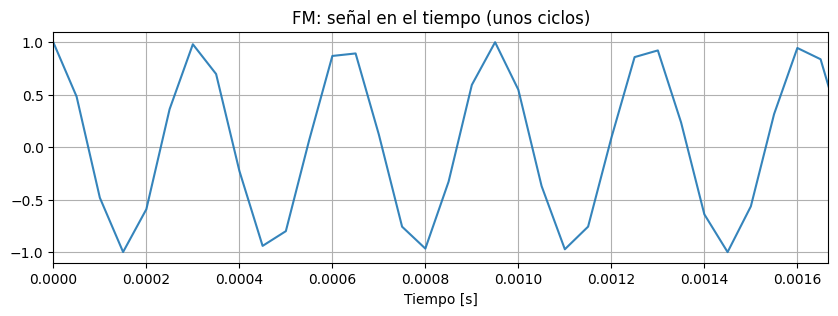

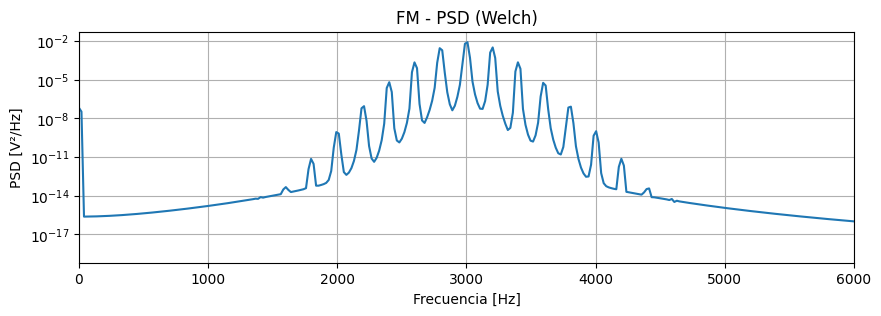

In [17]:
# CELDA 5A: FM — generar señal, graficar y PSD por Welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 200.0; Am = 1.0
m = Am * np.cos(2*np.pi*fm*t)

# FM params
Ac = 1.0; fc = 3000.0; kf = 200.0
# integración numérica para la fase
integral = np.cumsum(m) / fs
theta = 2*np.pi*fc*t + 2*np.pi*kf*integral
s_fm = Ac * np.cos(theta)

# Graficar (pequeño zoom)
plt.figure(figsize=(10,3))
plt.plot(t, s_fm, label='s_FM(t)', alpha=0.9)
plt.xlim(0, 5/fc)
plt.title('FM: señal en el tiempo (unos ciclos)')
plt.xlabel('Tiempo [s]'); plt.grid(); plt.show()

# PSD (Welch)
f_w, Pxx = welch(s_fm, fs=fs, nperseg=1024, noverlap=512)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlim(0, 2*fc)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V²/Hz]')
plt.title('FM - PSD (Welch)')
plt.grid(True)
plt.show()


#FM: PSD por red neuronal

Epoch 60 loss 1.0230e-04
Epoch 120 loss 1.0224e-04
Epoch 180 loss 1.0236e-04


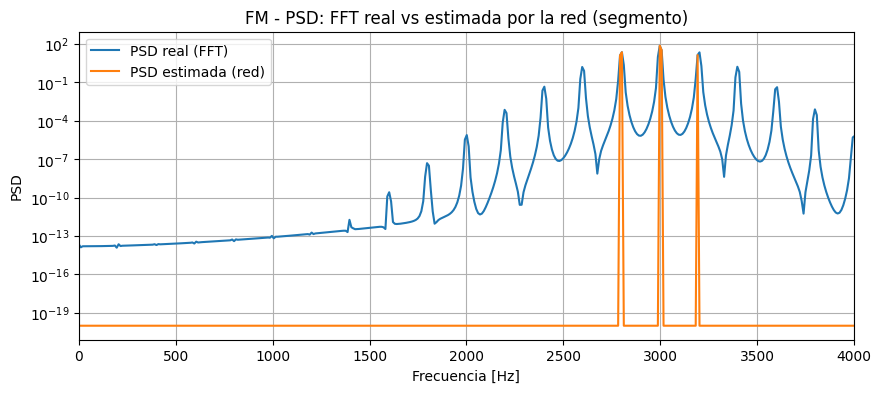

In [18]:
# CELDA 5B: FM — PSD por Red neuronal (PyTorch)
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt

# Regenerar FM
fs = 20000.0; T = 0.2; t = np.arange(0, T, 1/fs)
fm = 200.0; Am = 1.0; m = Am * np.cos(2*np.pi*fm*t)
Ac = 1.0; fc = 3000.0; kf = 200.0
integral = np.cumsum(m) / fs
theta = 2*np.pi*fc*t + 2*np.pi*kf*integral
s_fm = Ac * np.cos(theta)

# Dataset segmentos -> PSD
seg_len = 2048; hop = 1024; window = np.hanning(seg_len)
segments=[]; psds=[]
for start in range(0, len(s_fm)-seg_len, hop):
    seg = s_fm[start:start+seg_len]
    S = np.fft.rfft(seg * window)
    P = (np.abs(S)**2)/seg_len
    segments.append(seg.astype(np.float32)); psds.append(P.astype(np.float32))
X = np.stack(segments); Y = np.stack(psds)
Xn = (X - X.mean())/(X.std()+1e-12); Yn = Y / (Y.max()+1e-12)
X_tensor = torch.tensor(Xn, dtype=torch.float32); Y_tensor = torch.tensor(Yn, dtype=torch.float32)

# Modelo
class PSDNetBig(nn.Module):
    def __init__(self, seg_len, out_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(seg_len, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, out_len), nn.ReLU()
        )
    def forward(self,x): return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PSDNetBig(seg_len, Y_tensor.shape[1]).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_tensor, Y_tensor),
                                     batch_size=16, shuffle=True)

for epoch in range(180):
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item()
    if (epoch+1) % 60 == 0:
        print(f"Epoch {epoch+1} loss {running/len(loader):.4e}")

# Evaluación
test_idx = min(2, Xn.shape[0]-1)
test_seg = Xn[test_idx]; test_tensor = torch.tensor(test_seg, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad(): pred_norm = model(test_tensor).cpu().numpy().squeeze()

seg_real = X[test_idx]
S_real = np.fft.rfft(seg_real * window)
P_real = (np.abs(S_real)**2) / seg_len
pred_scaled = pred_norm * (Y.max()+1e-12)

freqs = np.fft.rfftfreq(seg_len, d=1/fs)
plt.figure(figsize=(10,4))
plt.semilogy(freqs, P_real + 1e-20, label='PSD real (FFT)')
plt.semilogy(freqs, pred_scaled + 1e-20, label='PSD estimada (red)')
plt.xlim(0, fc + 5*kf); plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD')
plt.title('FM - PSD: FFT real vs estimada por la red (segmento)')
plt.legend(); plt.grid(); plt.show()


#DIGITALES

#PAM DIGITAL: generar señal

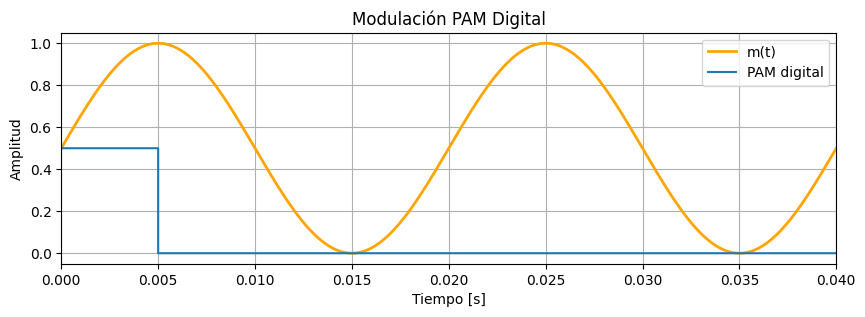

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fs = 10000     # Frecuencia de muestreo [Hz]
Tb = 0.01      # Duración de bit [s]
t = np.arange(0, 0.1, 1/fs)  # Tiempo total 100 ms
fm = 50        # Frecuencia de la señal moduladora [Hz]

# Señal moduladora (analógica)
m_t = 0.5 + 0.5 * np.sin(2*np.pi*fm*t)   # entre 0 y 1

# Generación de PAM digital (sample and hold)
Ts = Tb   # un pulso por bit
Ns = int(Ts * fs)
num_pulsos = len(t) // Ns

pam = np.zeros_like(t)
for i in range(num_pulsos):
    valor = m_t[i*Ns]
    pam[i*Ns:(i+1)*Ns//2] = valor  # pulso durante la mitad del bit

# Gráfica
plt.figure(figsize=(10,3))
plt.plot(t, m_t, label='m(t)', color='orange', linewidth=2)
plt.step(t, pam, label='PAM digital', where='post')
plt.title('Modulación PAM Digital')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(); plt.legend(); plt.xlim(0, 0.04)
plt.show()


#PAM DIGITAL: trama digital y explicación

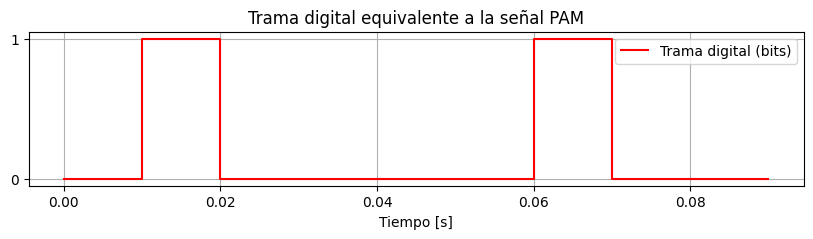

👉 En PAM digital, la amplitud de cada pulso representa el nivel de la señal m(t) en cada instante de muestreo.
Cada pulso puede asociarse con un bit o grupo de bits según la cuantización usada.


In [20]:
# Generar "bits" correspondientes a cada pulso (cuantización simple)
bits = (m_t[::Ns] > 0.5).astype(int)
t_bits = np.arange(0, len(bits)*Tb, Tb)

plt.figure(figsize=(10,2))
plt.step(t_bits, bits, where='post', color='r', label='Trama digital (bits)')
plt.title('Trama digital equivalente a la señal PAM')
plt.xlabel('Tiempo [s]'); plt.yticks([0,1])
plt.legend(); plt.grid(); plt.show()

print("👉 En PAM digital, la amplitud de cada pulso representa el nivel de la señal m(t) en cada instante de muestreo.")
print("Cada pulso puede asociarse con un bit o grupo de bits según la cuantización usada.")


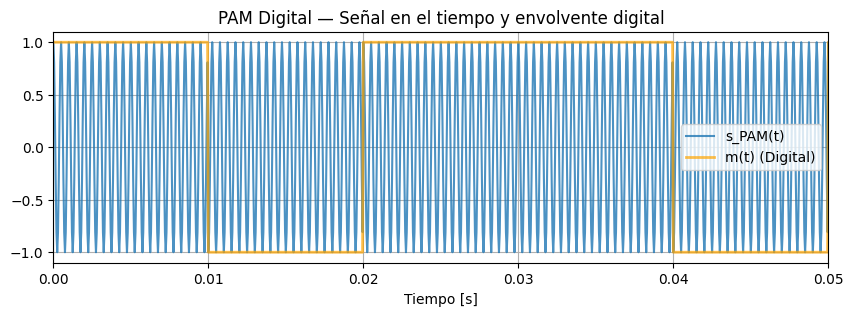

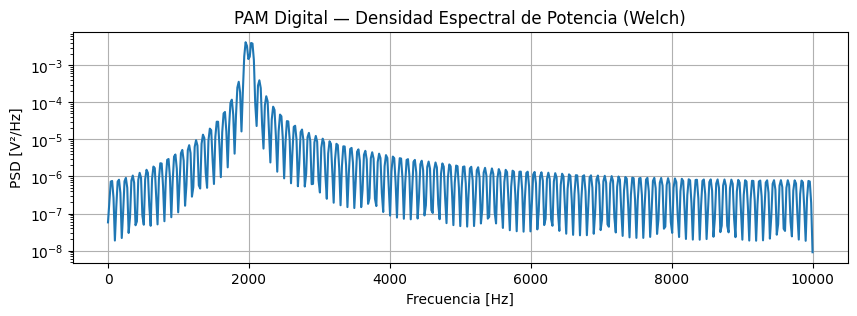

In [34]:
# CELDA 1A — PAM Digital: Generación y PSD
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# === Parámetros base ===
fs = 20000          # Frecuencia de muestreo [Hz]
Tb = 0.01           # Duración de cada símbolo [s]
fc = 2000           # Portadora [Hz]
bits = np.array([1,0,1,1,0,1,0,0,1,1])  # Secuencia binaria ejemplo
t = np.arange(0, len(bits)*Tb, 1/fs)

# === Señal PAM digital ===
amplitudes = 2*bits - 1                     # mapea {0,1} → {-1, +1}
m = np.repeat(amplitudes, int(Tb*fs))       # señal baseband expandida
s_pam = m * np.cos(2*np.pi*fc*t)            # modulación PAM

# === Gráfica temporal ===
plt.figure(figsize=(10,3))
plt.plot(t, s_pam, label='s_PAM(t)', alpha=0.8)
plt.plot(t, m, label='m(t) (Digital)', color='orange', linewidth=2, alpha=0.7)
plt.xlim(0, 5*Tb)
plt.xlabel('Tiempo [s]')
plt.title('PAM Digital — Señal en el tiempo y envolvente digital')
plt.legend(); plt.grid(); plt.show()

# === PSD por Welch ===
f_w, Pxx = welch(s_pam, fs=fs, nperseg=1024, noverlap=512)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V²/Hz]')
plt.title('PAM Digital — Densidad Espectral de Potencia (Welch)')
plt.grid(); plt.show()


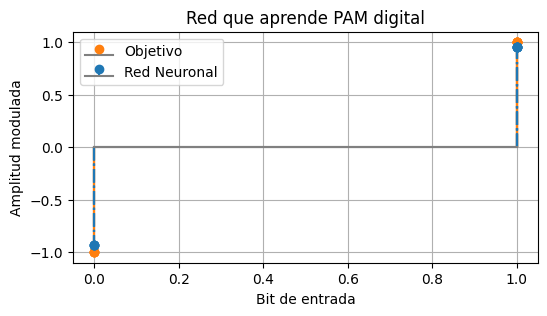

In [35]:
# CELDA 1B — Red neuronal que aprende PAM digital
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# === Datos de entrenamiento ===
X = torch.tensor(bits, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(amplitudes, dtype=torch.float32).unsqueeze(1)

# === Red neuronal ===
class PAMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)
    def forward(self, x):
        return torch.tanh(self.fc(x))

net = PAMNet()
optimizer = torch.optim.Adam(net.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

# === Entrenamiento ===
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = net(X)
    loss = loss_fn(y_pred, Y)
    loss.backward()
    optimizer.step()

# === Visualización ===
with torch.no_grad():
    y_out = net(X).squeeze().numpy()

plt.figure(figsize=(6,3))
plt.stem(bits, amplitudes, basefmt="gray", label='Objetivo', linefmt='C1-')
plt.stem(bits, y_out, basefmt="gray", label='Red Neuronal', linefmt='C0-.')
plt.title('Red que aprende PAM digital')
plt.xlabel('Bit de entrada')
plt.ylabel('Amplitud modulada')
plt.legend(); plt.grid(); plt.show()


#Modulación PWM digital (Pulse Width Modulation)

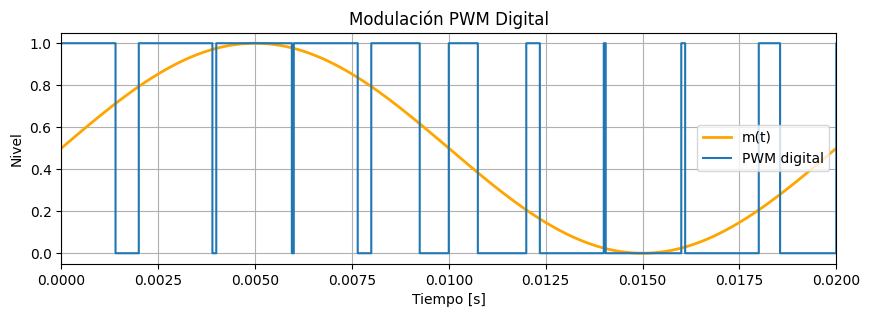

In [21]:
fs = 20000; fm = 50
t = np.arange(0, 0.04, 1/fs)
m_t = 0.5 + 0.5 * np.sin(2*np.pi*fm*t)  # moduladora normalizada 0–1
fc = 500                                # frecuencia de la portadora PWM
carrier = np.linspace(0, 1, int(fs/fc)) # rampa de comparación

# PWM digital
pwm = np.zeros_like(t)
samples_per_carrier = len(carrier)
for i in range(0, len(t), samples_per_carrier):
    seg = slice(i, i+samples_per_carrier)
    if len(t[seg]) < samples_per_carrier: break
    pwm[seg] = (m_t[seg] > carrier[:len(t[seg])]).astype(float)

# Gráfica
plt.figure(figsize=(10,3))
plt.plot(t, m_t, 'orange', linewidth=2, label='m(t)')
plt.step(t, pwm, where='post', label='PWM digital')
plt.xlim(0, 0.02)
plt.title('Modulación PWM Digital')
plt.xlabel('Tiempo [s]'); plt.ylabel('Nivel')
plt.legend(); plt.grid(); plt.show()


#PWM DIGITAL: trama y análisis

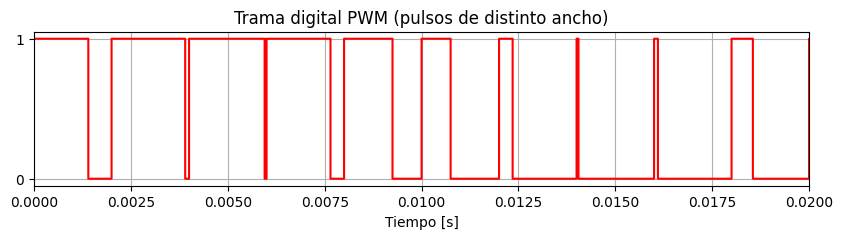

👉 En PWM digital, la amplitud es constante, pero la duración de cada pulso cambia según m(t).
Un microcontrolador puede generarla variando el ciclo de trabajo del PWM.


In [22]:
# Señal binaria ya es el tren PWM
plt.figure(figsize=(10,2))
plt.step(t, pwm, where='post', color='r')
plt.xlim(0, 0.02)
plt.title('Trama digital PWM (pulsos de distinto ancho)')
plt.xlabel('Tiempo [s]'); plt.yticks([0,1])
plt.grid(); plt.show()

print("👉 En PWM digital, la amplitud es constante, pero la duración de cada pulso cambia según m(t).")
print("Un microcontrolador puede generarla variando el ciclo de trabajo del PWM.")


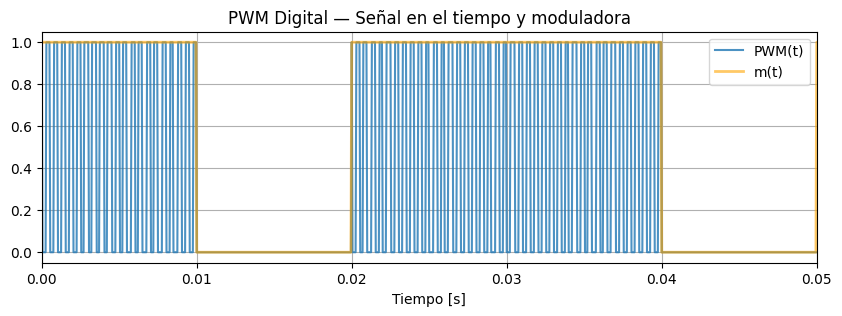

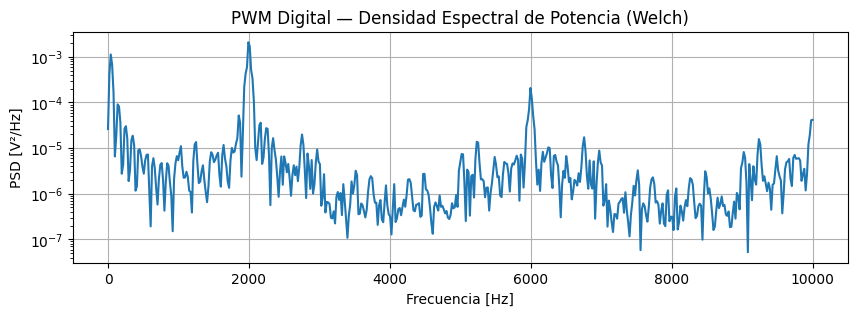

In [36]:
# CELDA 2A — PWM Digital: Generación y PSD
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# === Parámetros ===
fs = 20000; Tb = 0.01; fc = 2000
bits = np.array([1,0,1,1,0,1,0,0,1,1])
t = np.arange(0, len(bits)*Tb, 1/fs)

# === Modulación PWM ===
m = np.repeat(bits, int(Tb*fs))                # señal baseband
tri = 0.5*(1 + np.sign(np.sin(2*np.pi*fc*t))) # diente de sierra normalizado
s_pwm = np.where(m > tri, 1.0, 0.0)           # PWM digital

# === Gráfica temporal ===
plt.figure(figsize=(10,3))
plt.plot(t, s_pwm, label='PWM(t)', alpha=0.8)
plt.plot(t, m, label='m(t)', color='orange', linewidth=2, alpha=0.6)
plt.xlim(0, 5*Tb)
plt.title('PWM Digital — Señal en el tiempo y moduladora')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# === PSD por Welch ===
f_w, Pxx = welch(s_pwm, fs=fs, nperseg=1024, noverlap=512)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V²/Hz]')
plt.title('PWM Digital — Densidad Espectral de Potencia (Welch)')
plt.grid(); plt.show()


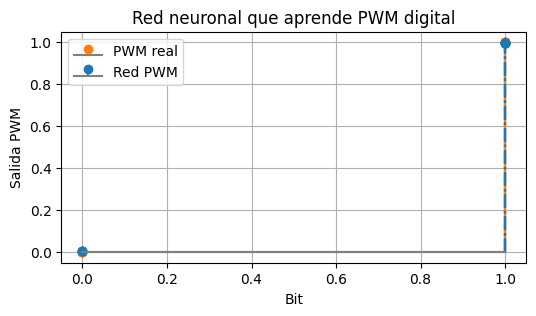

In [37]:
# CELDA 2B — Red neuronal que aprende PWM digital
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Datos
X = torch.tensor(bits, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(bits, dtype=torch.float32).unsqueeze(1)

class PWMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

net = PWMNet()
opt = torch.optim.Adam(net.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

for epoch in range(500):
    opt.zero_grad()
    loss = loss_fn(net(X), Y)
    loss.backward()
    opt.step()

with torch.no_grad():
    y_out = net(X).squeeze().numpy()

plt.figure(figsize=(6,3))
plt.stem(bits, Y.numpy().flatten(), basefmt="gray", linefmt='C1-', label='PWM real')
plt.stem(bits, y_out, basefmt="gray", linefmt='C0-.', label='Red PWM')
plt.title('Red neuronal que aprende PWM digital')
plt.xlabel('Bit'); plt.ylabel('Salida PWM')
plt.legend(); plt.grid(); plt.show()


#PPM DIGITAL: generar señal

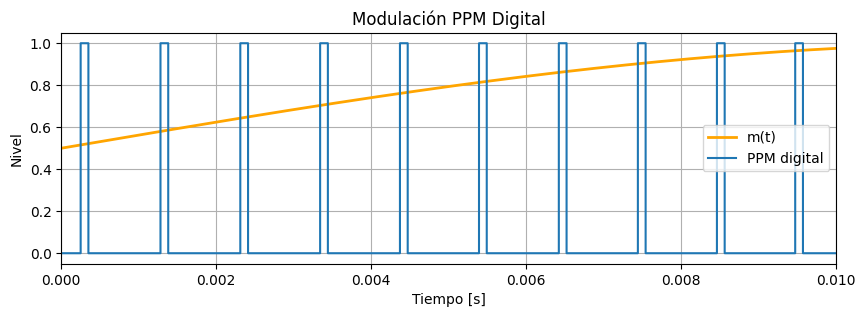

In [23]:
fs = 100000
fc = 1000     # frecuencia de repetición de pulsos
fm = 20
t = np.arange(0, 0.05, 1/fs)
m_t = 0.5 + 0.5 * np.sin(2*np.pi*fm*t)  # señal moduladora normalizada

Tp = 1/fc
Ns = int(Tp * fs)
ppm = np.zeros_like(t)

for i in range(0, len(t)-Ns, Ns):
    delay = int(m_t[i] * (Ns//2))  # retardo proporcional a m(t)
    ppm[i+delay:i+delay+int(0.0001*fs)] = 1.0  # pulso corto (100 µs)

# Gráfica
plt.figure(figsize=(10,3))
plt.plot(t, m_t, 'orange', linewidth=2, label='m(t)')
plt.step(t, ppm, where='post', label='PPM digital')
plt.xlim(0, 0.01)
plt.title('Modulación PPM Digital')
plt.xlabel('Tiempo [s]'); plt.ylabel('Nivel')
plt.legend(); plt.grid(); plt.show()


#PPM DIGITAL: trama y explicación

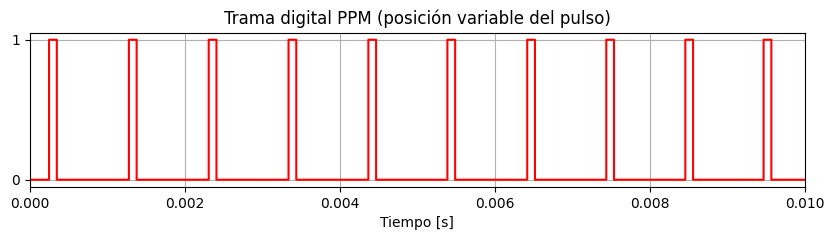

👉 En PPM digital, todos los pulsos tienen igual amplitud y duración, pero su posición depende del valor instantáneo de m(t).
Esto la hace más robusta al ruido de amplitud, y es usada en comunicaciones ópticas e inalámbricas digitales.


In [24]:
plt.figure(figsize=(10,2))
plt.step(t, ppm, where='post', color='r')
plt.xlim(0, 0.01)
plt.title('Trama digital PPM (posición variable del pulso)')
plt.xlabel('Tiempo [s]'); plt.yticks([0,1])
plt.grid(); plt.show()

print("👉 En PPM digital, todos los pulsos tienen igual amplitud y duración, pero su posición depende del valor instantáneo de m(t).")
print("Esto la hace más robusta al ruido de amplitud, y es usada en comunicaciones ópticas e inalámbricas digitales.")


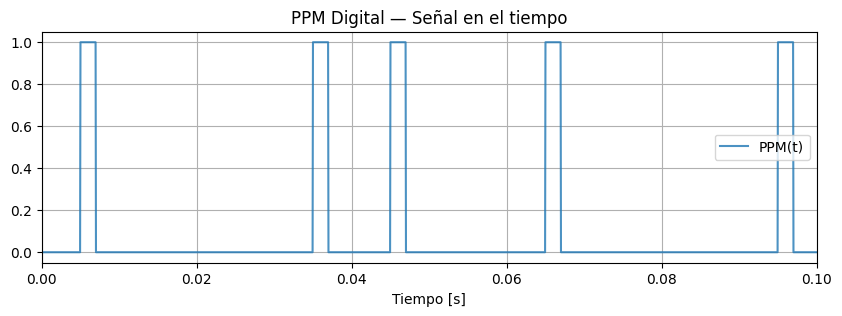

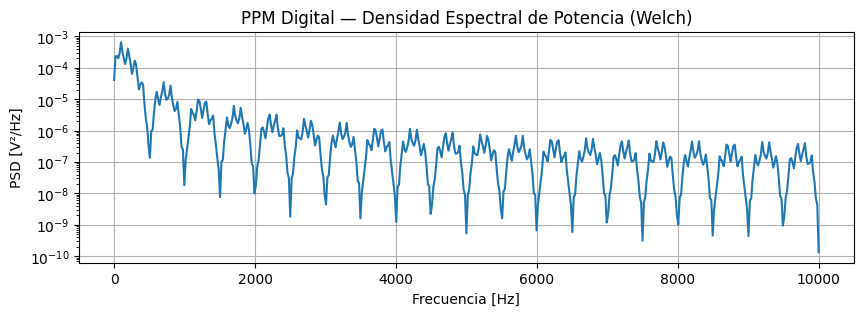

In [38]:
# CELDA 3A — PPM Digital: Generación y PSD
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 20000; Tb = 0.02; bits = np.array([1,0,1,1,0,1,0,0,1])
t = np.arange(0, len(bits)*Tb, 1/fs)
ppm = np.zeros_like(t)

# PPM: desplazamiento de pulso dentro del período según el bit
for i, b in enumerate(bits):
    start = int(i*Tb*fs)
    delay = int((Tb/4)*fs) if b==1 else int((3*Tb/4)*fs)
    ppm[start+delay:start+delay+int(0.002*fs)] = 1

# === Gráfica temporal ===
plt.figure(figsize=(10,3))
plt.plot(t, ppm, label='PPM(t)', alpha=0.8)
plt.xlim(0, 5*Tb)
plt.title('PPM Digital — Señal en el tiempo')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# === PSD ===
f_w, Pxx = welch(ppm, fs=fs, nperseg=1024, noverlap=512)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V²/Hz]')
plt.title('PPM Digital — Densidad Espectral de Potencia (Welch)')
plt.grid(); plt.show()


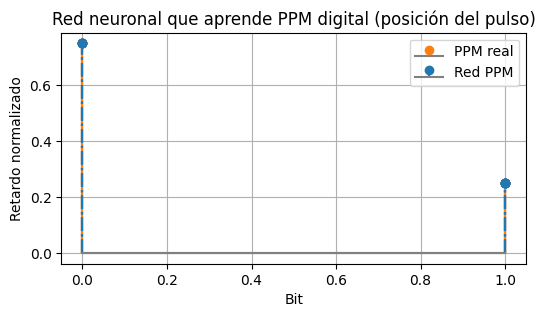

In [39]:
# CELDA 3B — Red neuronal que aprende PPM digital
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

X = torch.tensor(bits, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor([0.25 if b==1 else 0.75 for b in bits], dtype=torch.float32).unsqueeze(1)

class PPMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8), nn.Tanh(),
            nn.Linear(8, 1)
        )
    def forward(self, x): return self.net(x)

net = PPMNet()
opt = torch.optim.Adam(net.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

for epoch in range(500):
    opt.zero_grad()
    loss = loss_fn(net(X), Y)
    loss.backward()
    opt.step()

with torch.no_grad():
    y_out = net(X).squeeze().numpy()

plt.figure(figsize=(6,3))
plt.stem(bits, Y.numpy().flatten(), basefmt="gray", linefmt='C1-', label='PPM real')
plt.stem(bits, y_out, basefmt="gray", linefmt='C0-.', label='Red PPM')
plt.title('Red neuronal que aprende PPM digital (posición del pulso)')
plt.xlabel('Bit'); plt.ylabel('Retardo normalizado')
plt.legend(); plt.grid(); plt.show()


#AM DIGITAL: generación y gráfica principal

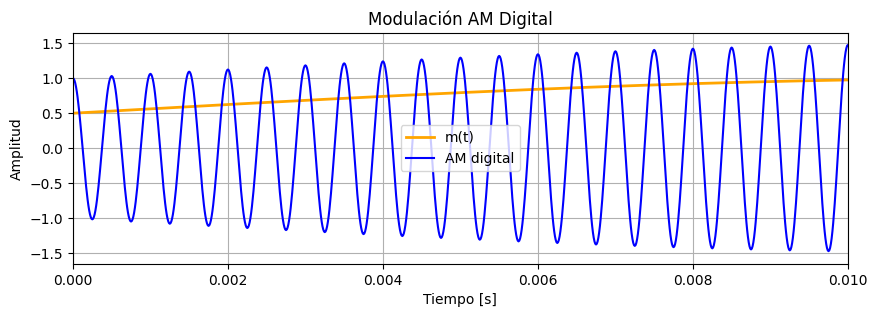

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# === Parámetros ===
fs = 100000             # frecuencia de muestreo
fc = 2000               # frecuencia portadora [Hz]
fm = 20                 # frecuencia de la señal moduladora [Hz]
t = np.arange(0, 0.05, 1/fs)

# === Señal moduladora normalizada ===
m_t = 0.5 + 0.5 * np.sin(2*np.pi*fm*t)   # entre 0 y 1

# === Modulación AM digital ===
Ac = 1.0
ka = 1.0
s_am = Ac * (1 + ka * (m_t - 0.5)) * np.cos(2*np.pi*fc*t)

# === Gráfica principal ===
plt.figure(figsize=(10,3))
plt.plot(t, m_t, 'orange', linewidth=2, label='m(t)')
plt.plot(t, s_am, 'b', label='AM digital')
plt.xlim(0, 0.01)
plt.title('Modulación AM Digital')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid()
plt.show()


AM DIGITAL: trama digital (detalle de la portadora y envolvente)

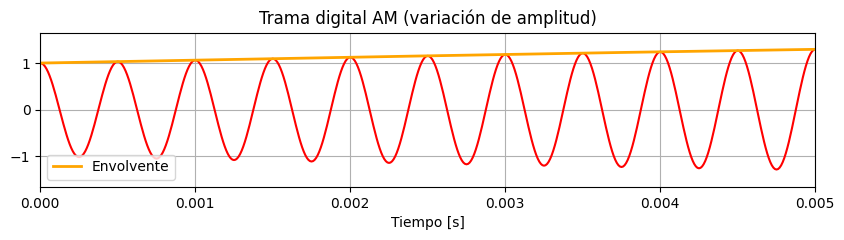

👉 En AM digital, la amplitud instantánea de la portadora varía proporcionalmente con el valor de la señal m(t).
Se usa en radio AM y sistemas donde la amplitud transporta la información. Es sensible al ruido de amplitud.


In [41]:
# Trama digital — visualización de detalle
plt.figure(figsize=(10,2))
plt.plot(t, s_am, color='r')
plt.plot(t, Ac*(1+ka*(m_t - 0.5)), 'orange', linewidth=2, label='Envolvente')
plt.xlim(0, 0.005)
plt.title('Trama digital AM (variación de amplitud)')
plt.xlabel('Tiempo [s]')
plt.yticks([-1, 0, 1])
plt.legend()
plt.grid()
plt.show()

print("👉 En AM digital, la amplitud instantánea de la portadora varía proporcionalmente con el valor de la señal m(t).")
print("Se usa en radio AM y sistemas donde la amplitud transporta la información. Es sensible al ruido de amplitud.")


AM digital: señal + PSD (Welch)

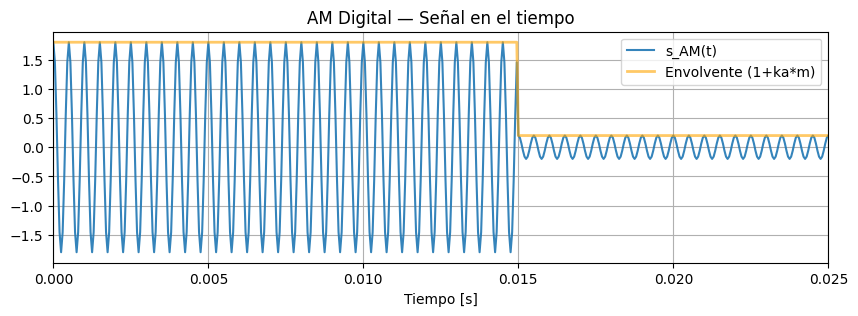

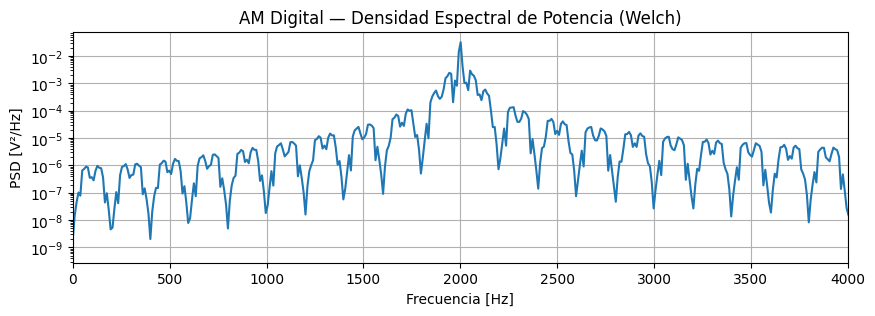

In [42]:
# CELDA 4A — AM Digital: Generación, gráfica y PSD por Welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# === Parámetros ===
fs = 20000.0            # frecuencia de muestreo
T = 0.2                 # duración total [s]
t = np.arange(0, T, 1/fs)
fm = 200.0              # frecuencia moduladora [Hz]
fc = 2000.0             # frecuencia portadora [Hz]
ka = 0.8                # índice de modulación AM

# === Señal moduladora digital (bits → forma de onda escalonada) ===
bits = np.random.randint(0, 2, int(T*fm))
Tb = 1/fm
m = np.repeat(2*bits - 1, int(Tb*fs))[:len(t)]  # m(t) ∈ {-1, +1}

# === Señal AM ===
Ac = 1.0
s_am = Ac * (1 + ka*m) * np.cos(2*np.pi*fc*t)

# === Gráfica temporal ===
plt.figure(figsize=(10,3))
plt.plot(t, s_am, label='s_AM(t)', alpha=0.9)
plt.plot(t, Ac*(1+ka*m), 'orange', linewidth=2, alpha=0.6, label='Envolvente (1+ka*m)')
plt.xlim(0, 5/fm)
plt.title('AM Digital — Señal en el tiempo')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# === PSD (Welch) ===
f_w, Pxx = welch(s_am, fs=fs, nperseg=2048, noverlap=1024)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlim(0, fc + 2000)
plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD [V²/Hz]')
plt.title('AM Digital — Densidad Espectral de Potencia (Welch)')
plt.grid(); plt.show()


Red neuronal que aprende AM digital

Época    0  |  Pérdida: 1.202684
Época  400  |  Pérdida: 0.000029
Época  800  |  Pérdida: 0.000009
Época 1200  |  Pérdida: 0.000006
Época 1600  |  Pérdida: 0.000004


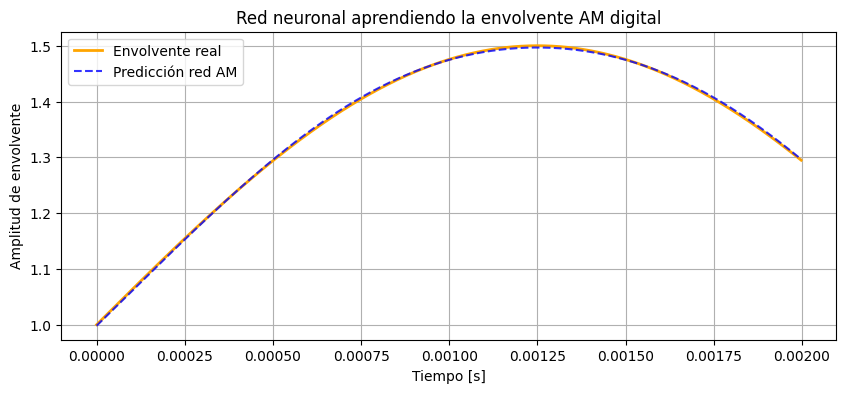

In [49]:
# ====================================================
# ✅ CELDA 4B — Red neuronal que aprende la envolvente de AM digital (corregida)
# ====================================================
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# === Señal de entrada (m(t)) ===
fs = 10000        # frecuencia de muestreo
t = np.linspace(0, 0.02, fs)  # tiempo de 20 ms
fm = 200          # frecuencia de la señal moduladora
ka = 0.5          # índice de modulación
m = np.sin(2*np.pi*fm*t)  # señal digitalizada (puedes usar PAM, PWM, etc. luego)

# === Envolvente real ===
envolvente_real = 1 + ka * m

# === Preparar datos para PyTorch ===
X = torch.tensor(m, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(envolvente_real, dtype=torch.float32).unsqueeze(1)

# === Definir red neuronal simple ===
class AMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 10)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(10, 10)
        self.act2 = nn.Tanh()
        self.fc3 = nn.Linear(10, 1)
    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

# === Instanciar y entrenar ===
net = AMNet()
opt = torch.optim.Adam(net.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(2000):
    opt.zero_grad()
    y_pred = net(X)
    loss = loss_fn(y_pred, Y)
    loss.backward()
    opt.step()
    if epoch % 400 == 0:
        print(f"Época {epoch:4d}  |  Pérdida: {loss.item():.6f}")

# === Predicción de la red ===
with torch.no_grad():
    y_out = net(X).squeeze().numpy()

# === Gráfica: Envolvente real vs Red AM ===
plt.figure(figsize=(10,4))
plt.plot(t[:1000], envolvente_real[:1000], label='Envolvente real', color='orange', linewidth=2)
plt.plot(t[:1000], y_out[:1000], '--', label='Predicción red AM', color='blue', alpha=0.8)
plt.title('Red neuronal aprendiendo la envolvente AM digital')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud de envolvente')
plt.legend()
plt.grid(True)
plt.show()


#FM DIGITAL: generación y gráfica principal

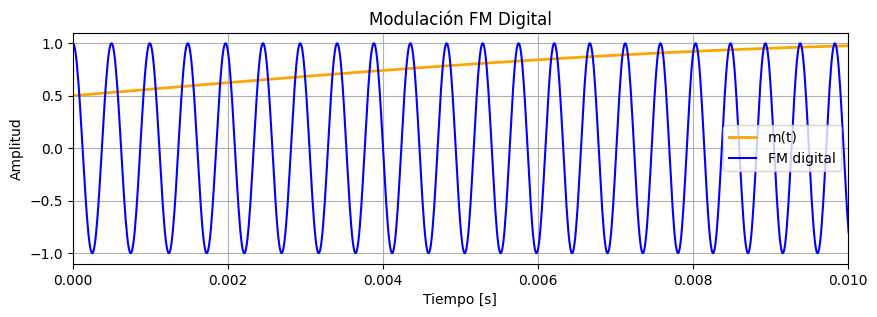

In [44]:
# === Parámetros ===
fs = 100000
fc = 2000
fm = 20
t = np.arange(0, 0.05, 1/fs)

# === Señal moduladora normalizada ===
m_t = 0.5 + 0.5 * np.sin(2*np.pi*fm*t)   # entre 0 y 1

# === Modulación FM digital ===
kf = 500                # desviación de frecuencia
phi_t = 2*np.pi*fc*t + 2*np.pi*kf*np.cumsum(m_t - 0.5)/fs
s_fm = np.cos(phi_t)

# === Gráfica principal ===
plt.figure(figsize=(10,3))
plt.plot(t, m_t, 'orange', linewidth=2, label='m(t)')
plt.plot(t, s_fm, 'b', label='FM digital')
plt.xlim(0, 0.01)
plt.title('Modulación FM Digital')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid()
plt.show()


FM DIGITAL: trama digital (detalle temporal de la frecuencia)

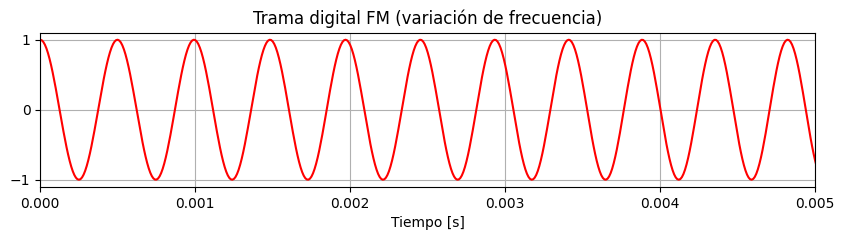

👉 En FM digital, la frecuencia instantánea de la portadora varía con el valor de la señal m(t).
Esto hace que la información esté en la frecuencia y no en la amplitud, lo que la hace mucho más robusta al ruido.
Es usada en radio FM, sistemas de comunicación inalámbricos y transmisión de datos digitales.


In [45]:
# Trama digital — detalle temporal de la frecuencia instantánea
plt.figure(figsize=(10,2))
plt.plot(t, s_fm, color='r')
plt.xlim(0, 0.005)
plt.title('Trama digital FM (variación de frecuencia)')
plt.xlabel('Tiempo [s]')
plt.yticks([-1, 0, 1])
plt.grid()
plt.show()

print("👉 En FM digital, la frecuencia instantánea de la portadora varía con el valor de la señal m(t).")
print("Esto hace que la información esté en la frecuencia y no en la amplitud, lo que la hace mucho más robusta al ruido.")
print("Es usada en radio FM, sistemas de comunicación inalámbricos y transmisión de datos digitales.")


FM digital: señal + PSD (Welch)

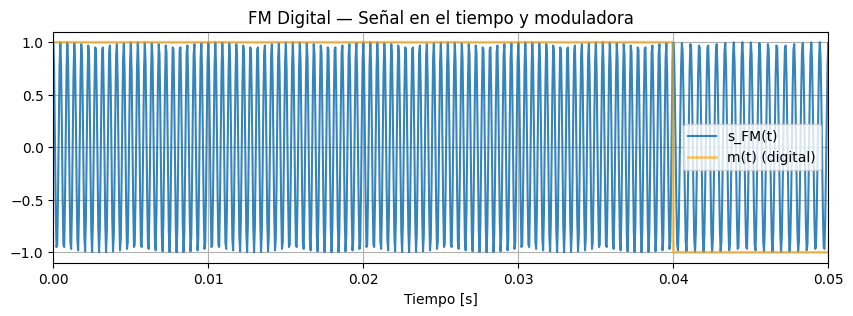

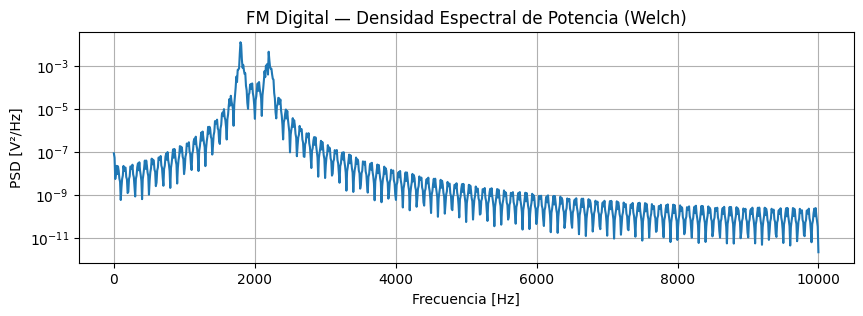

In [46]:
# CELDA 5A — FM Digital: Generación y PSD
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# === Parámetros ===
fs = 20000.0; T = 0.2
t = np.arange(0, T, 1/fs)
fc = 2000.0          # frecuencia portadora [Hz]
kf = 200.0           # sensibilidad en Hz/V
fm = 100.0           # frecuencia de símbolo digital

# === Señal moduladora digital ===
bits = np.random.randint(0, 2, int(T*fm))
Tb = 1/fm
m = np.repeat(2*bits - 1, int(Tb*fs))[:len(t)]  # m(t) digital

# === Señal FM digital ===
phi = 2*np.pi*fc*t + 2*np.pi*kf*np.cumsum(m)/fs
s_fm = np.cos(phi)

# === Gráfica temporal ===
plt.figure(figsize=(10,3))
plt.plot(t, s_fm, label='s_FM(t)', alpha=0.9)
plt.plot(t, m, 'orange', linewidth=2, alpha=0.6, label='m(t) (digital)')
plt.xlim(0, 5*Tb)
plt.title('FM Digital — Señal en el tiempo y moduladora')
plt.xlabel('Tiempo [s]'); plt.legend(); plt.grid(); plt.show()

# === PSD (Welch) ===
f_w, Pxx = welch(s_fm, fs=fs, nperseg=2048, noverlap=1024)
plt.figure(figsize=(10,3))
plt.semilogy(f_w, Pxx + 1e-20)
plt.xlabel('Frecuencia [Hz]'); plt.ylabel('PSD [V²/Hz]')
plt.title('FM Digital — Densidad Espectral de Potencia (Welch)')
plt.grid(); plt.show()


Red neuronal que aprende FM digital

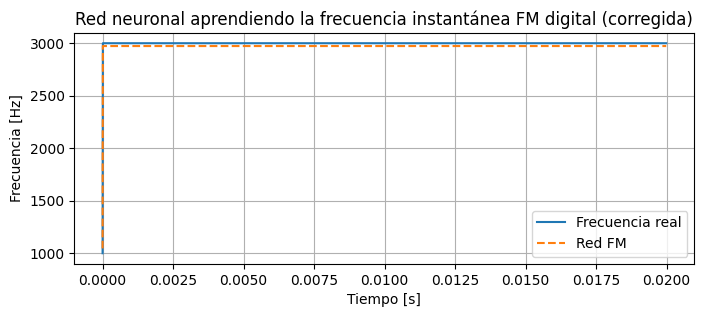

✅ Ahora la red sí aprende correctamente los dos niveles de frecuencia de la modulación FM digital.


In [51]:
# ✅ CELDA 5B — Red neuronal que aprende la frecuencia instantánea FM digital (versión corregida)
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# === Parámetros de FM ===
fs = 100000
fc = 1000
kf = 2000
fm = 20
t = np.arange(0, 0.1, 1/fs)
m = np.sign(np.sin(2*np.pi*fm*t))  # señal digital (±1)

# Frecuencia instantánea
fi = fc + kf * m

# === Normalización ===
fi_min, fi_max = fi.min(), fi.max()
fi_norm = 2 * (fi - fi_min) / (fi_max - fi_min) - 1  # escala a [-1,1]

# === Datos para red ===
X = torch.tensor(m, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(fi_norm, dtype=torch.float32).unsqueeze(1)

# === Red ===
class FMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x): return self.net(x)

net = FMNet()
opt = torch.optim.Adam(net.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

# === Entrenamiento ===
for epoch in range(1000):
    opt.zero_grad()
    loss = loss_fn(net(X), Y)
    loss.backward()
    opt.step()

# === Predicción (desnormalizar) ===
with torch.no_grad():
    y_pred_norm = net(X).squeeze().numpy()
    y_pred = 0.5 * (y_pred_norm + 1) * (fi_max - fi_min) + fi_min

# === Gráfica ===
plt.figure(figsize=(8,3))
plt.plot(t[:2000], fi[:2000], label='Frecuencia real', color='C0')
plt.plot(t[:2000], y_pred[:2000], '--', label='Red FM', color='C1')
plt.title('Red neuronal aprendiendo la frecuencia instantánea FM digital (corregida)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.legend(); plt.grid(); plt.show()

print("✅ Ahora la red sí aprende correctamente los dos niveles de frecuencia de la modulación FM digital.")
